# CSC3831 Final Assessment - Part I: Data Engineering



In [2]:
# Loading in standard packages for analysis, feel free to add an extra packages you'd like to use here
import random
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
# Loading in the corrupted dataset to be used in analysis and imputation
houses_corrupted = pd.read_csv('https://raw.githubusercontent.com/PaoloMissier/CSC3831-2021-22/main/IMPUTATION/TARGET-DATASETS/CORRUPTED/HOUSES/houses_0.1_MAR.csv', header=0)
# Remove an artifact from the dataset
houses_corrupted.drop(["Unnamed: 0"], axis=1, inplace=True)

Above we've loaded in a corrupted version of a housing dataset. The anomalies need to be dealt with and missing values imputed.

### 1. Data Understanding [7]
- Perform ad hoc EDA to understand and describe what you see in the raw dataset
  - Include graphs, statistics, and written descriptions as appropriate
  - Any extra information about the data you can provide here is useful, think about performing an analysis (ED**A**), what would you find interesting or useful?
- Identify features with missing records, outlier records


In [2]:
houses_corrupted.head()
houses_corrupted.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   median_house_value  20640 non-null  float64
 1   median_income       18576 non-null  float64
 2   housing_median_age  18576 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          18576 non-null  float64
 6   households          20640 non-null  float64
 7   latitude            20640 non-null  float64
 8   longitude           20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [3]:
houses_corrupted.describe()

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
count,20640.000000,18576.000000,18576.000000,20640.000000,20640.000000,18576.000000,20640.000000,20640.000000,20640.000000
mean,206855.816909,3.929958,28.324182,2635.763081,537.898014,1488.069283,499.539680,35.631861,-119.569704
std,115395.615874,1.964296,12.584914,2181.615252,421.247906,1170.585810,382.329753,2.135952,2.003532
min,14999.000000,0.499900,1.000000,2.000000,1.000000,3.000000,1.000000,32.540000,-124.350000
25%,119600.000000,2.560300,18.000000,1447.750000,295.000000,839.000000,280.000000,33.930000,-121.800000
50%,179700.000000,3.572400,28.000000,2127.000000,435.000000,1227.000000,409.000000,34.260000,-118.490000
75%,264725.000000,4.870050,37.000000,3148.000000,647.000000,1803.000000,605.000000,37.710000,-118.010000
max,500001.000000,15.000100,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,41.950000,-114.310000


<Axes: >

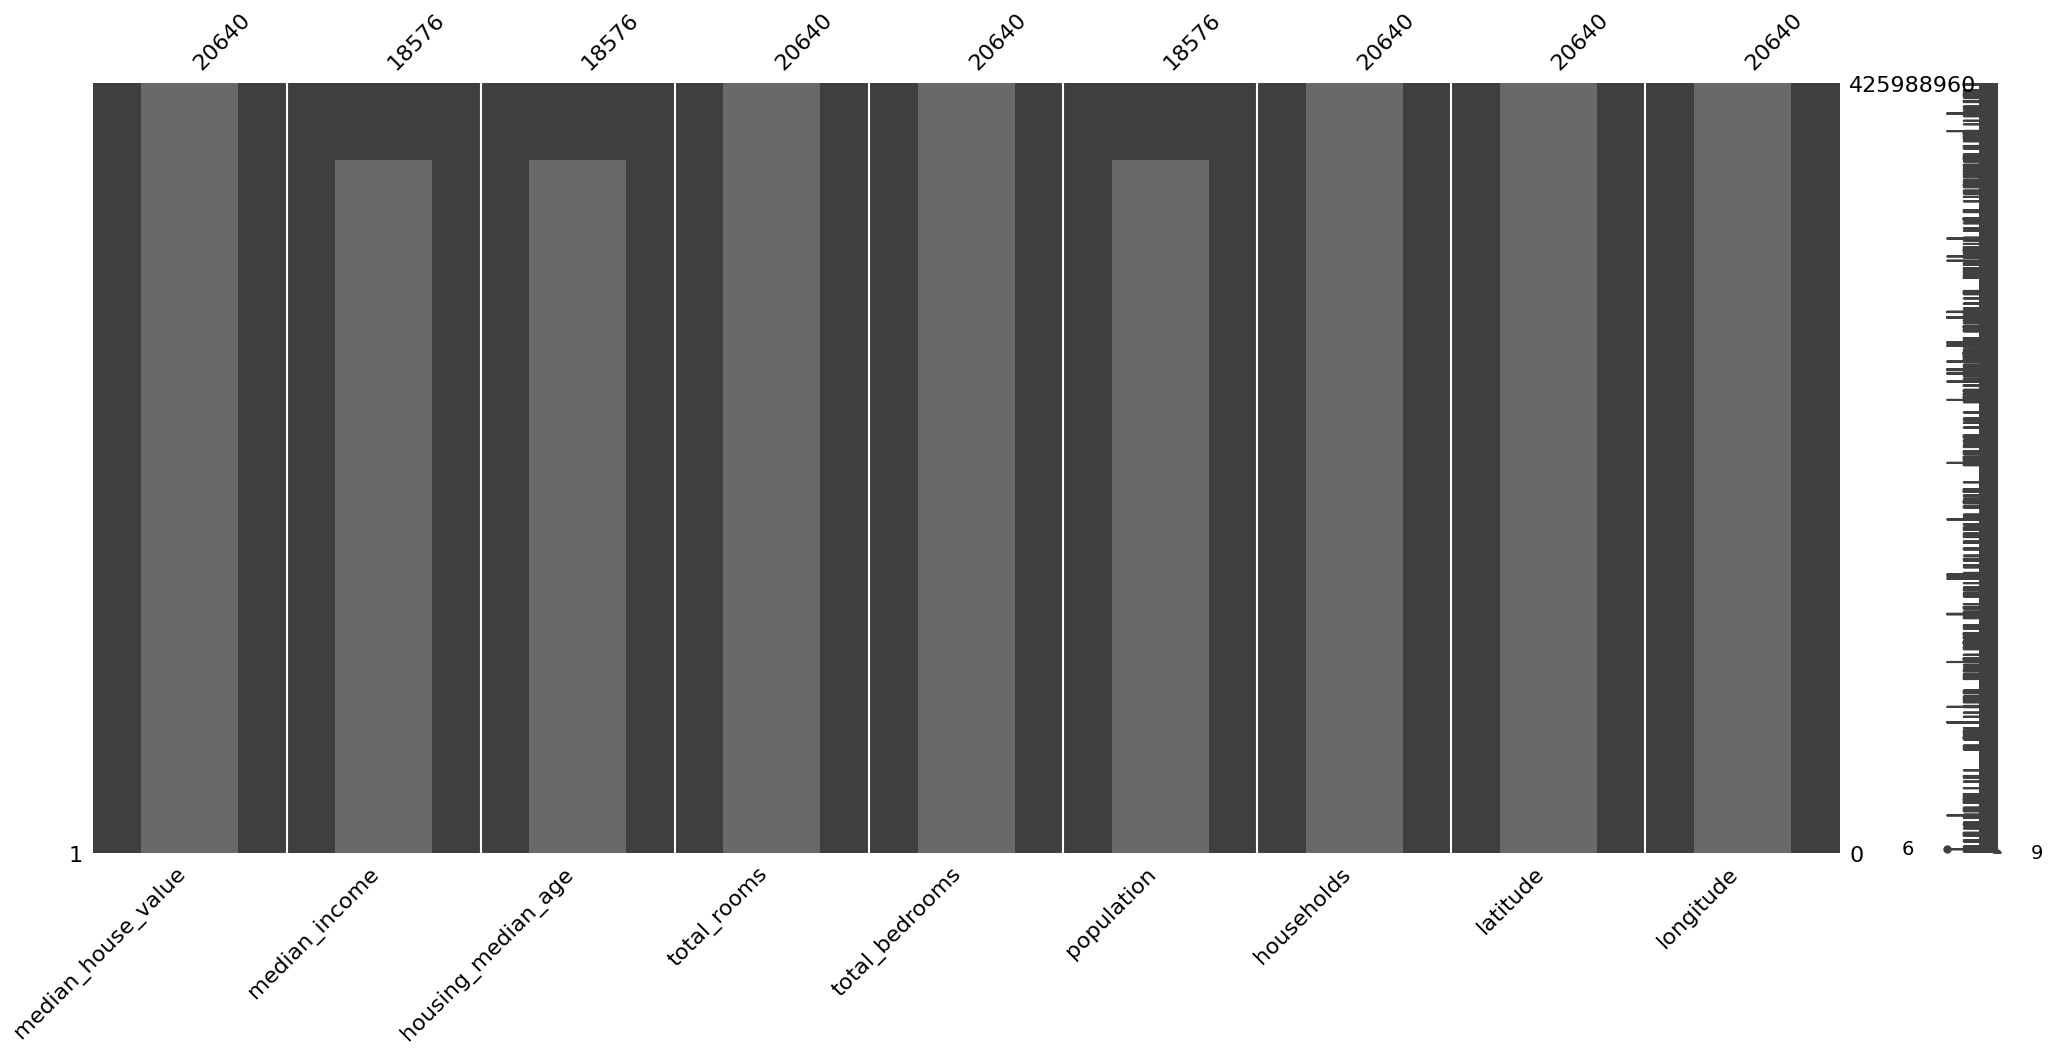

In [4]:
msno.matrix(houses_corrupted)
msno.bar(houses_corrupted)

In [5]:
houses_corrupted.isnull().sum()

,0
median_house_value,0
median_income,2064
housing_median_age,2064
total_rooms,0
total_bedrooms,0
population,2064
households,0
latitude,0
longitude,0


In [6]:
print("\nMissing Values Count:")
missing_values = houses_corrupted.isnull().sum()
display(missing_values[missing_values > 0])


Missing Values Count:


,0
median_income,2064
housing_median_age,2064
population,2064


### Missing Values
- Displayed missing value counts for all features.

- Observed patterns in missing data using visualizations (missingno.matrix and missingno.bar).

- Noted key features with significant missingness.

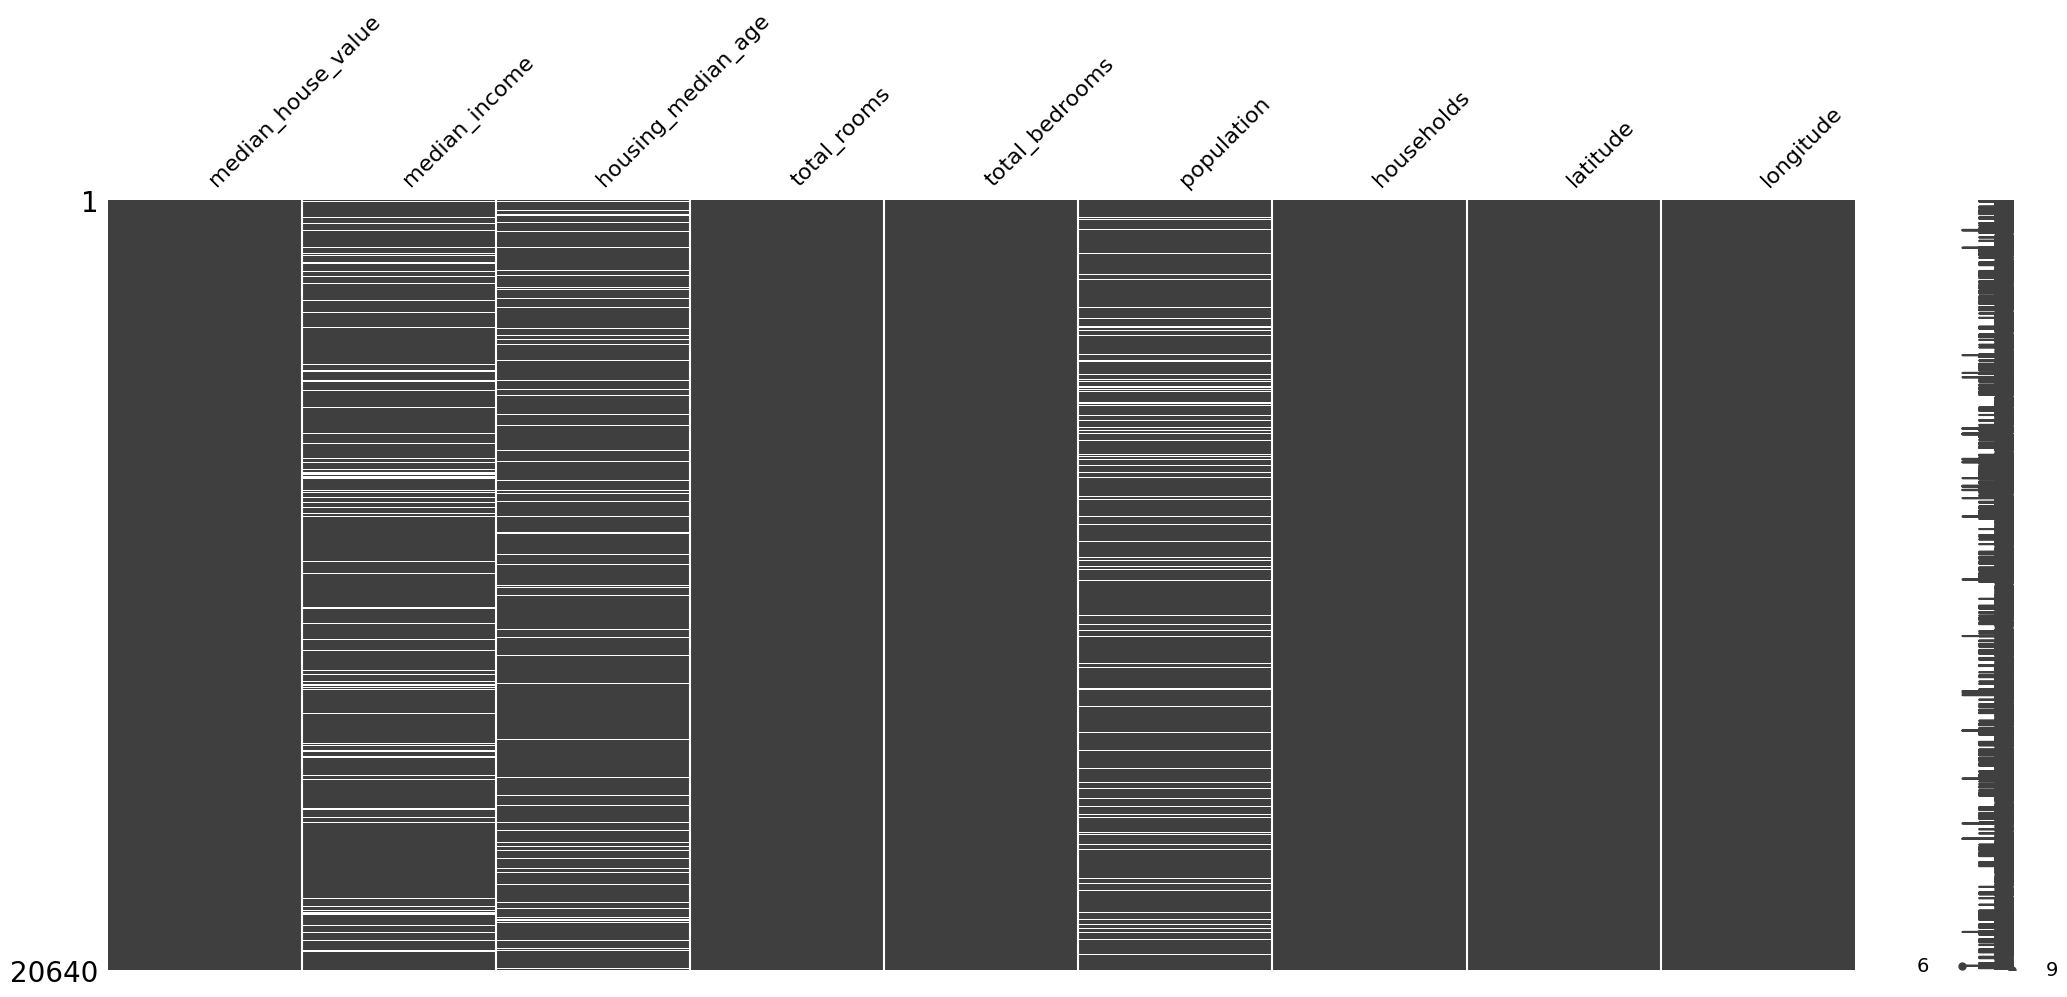

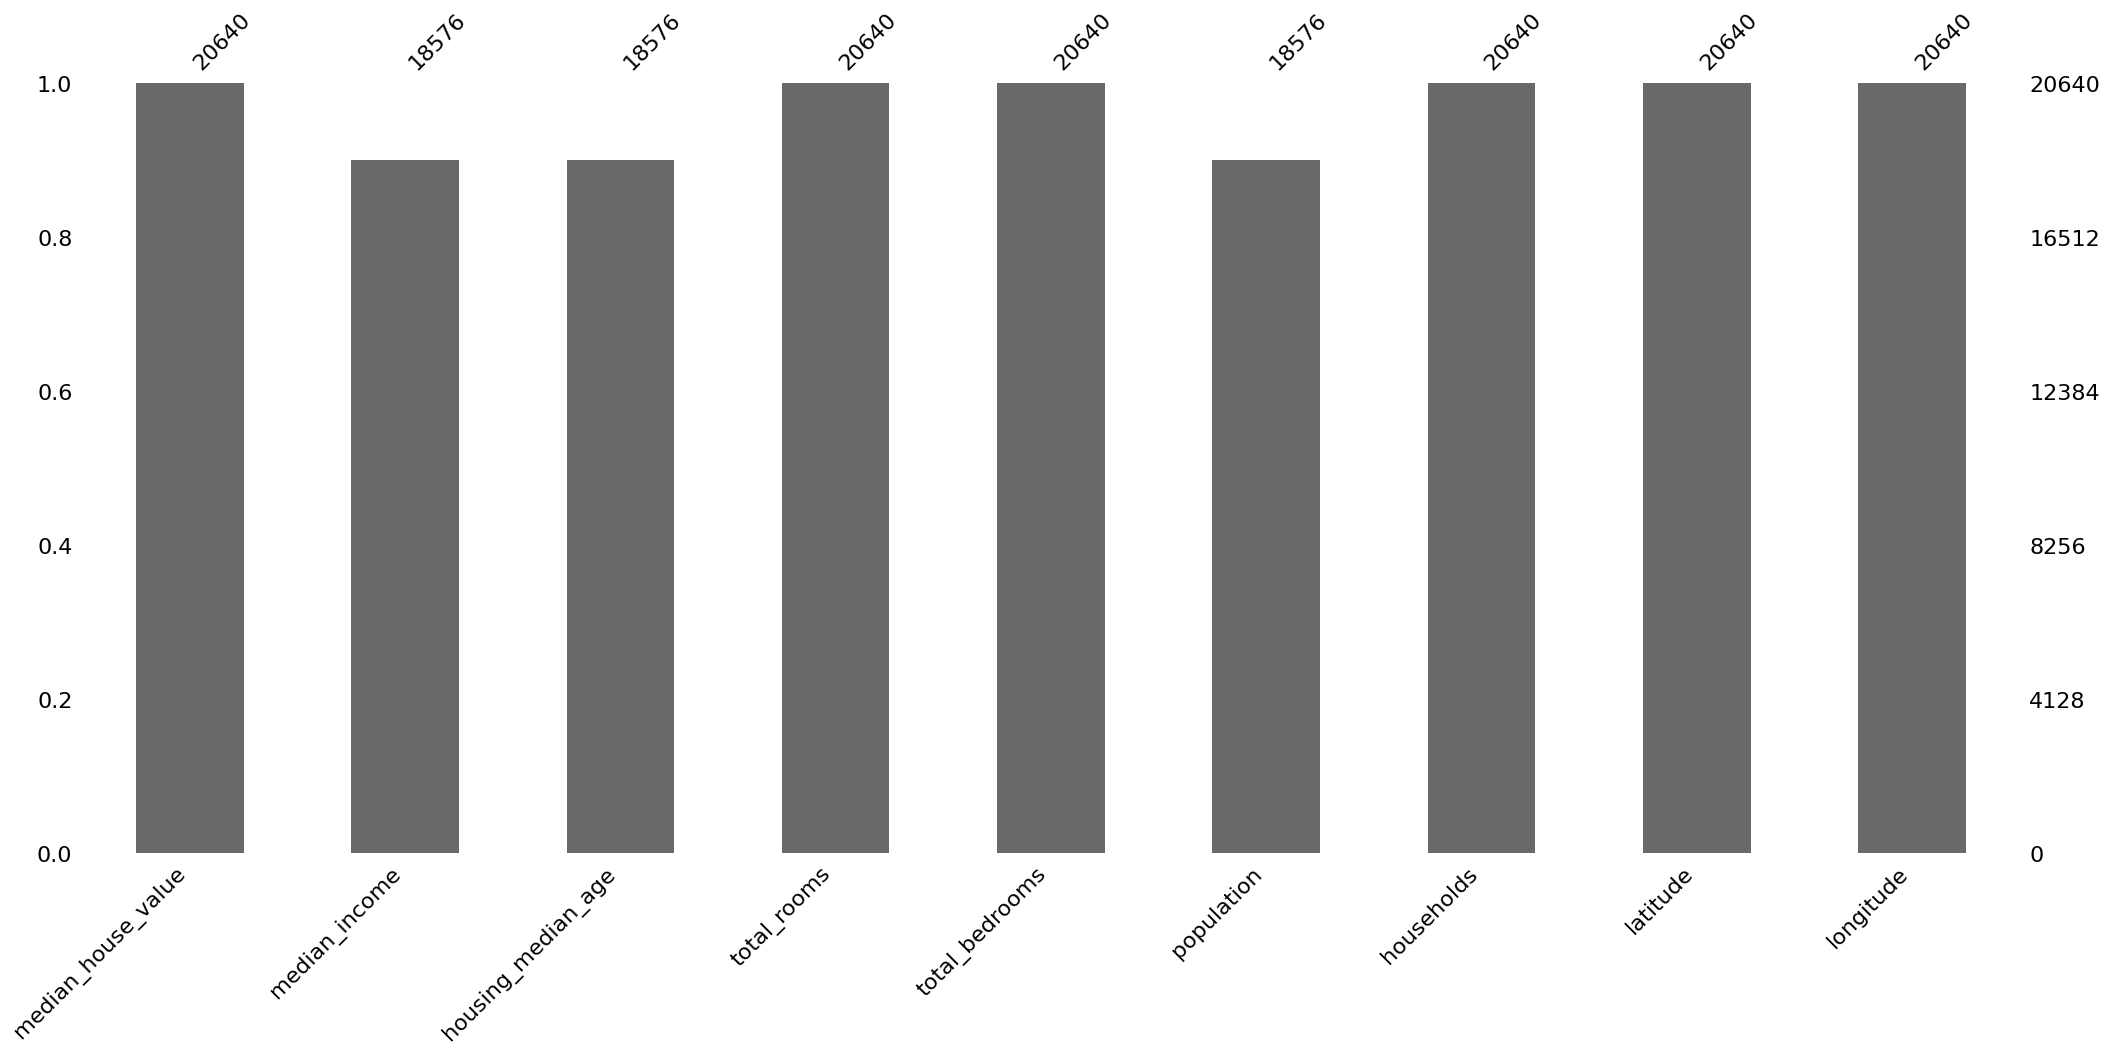

In [7]:
import matplotlib.pyplot as plt
msno.matrix(houses_corrupted)
plt.show()

msno.bar(houses_corrupted)
plt.show()


Detecting Outliers Using Boxplots:


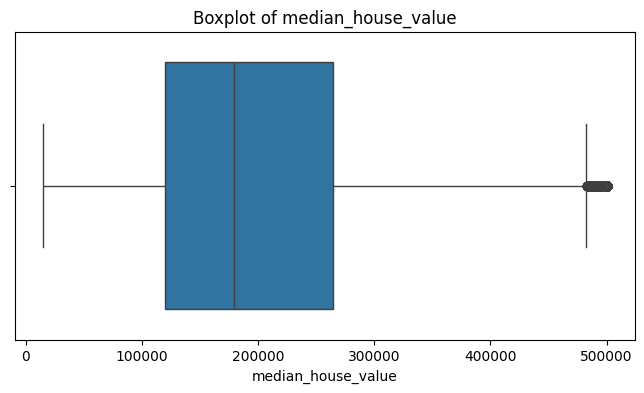

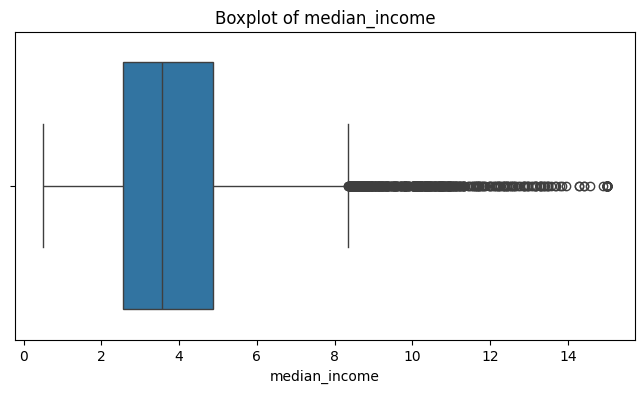

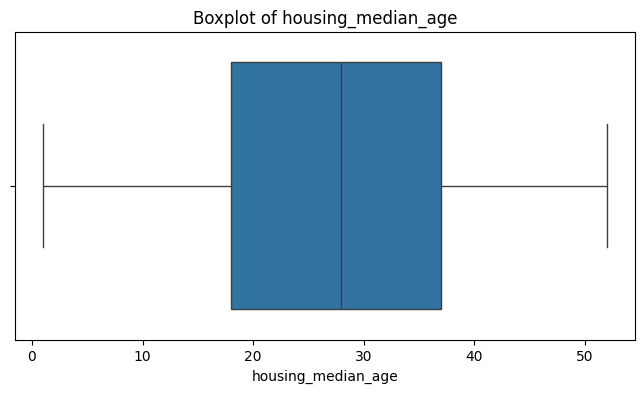

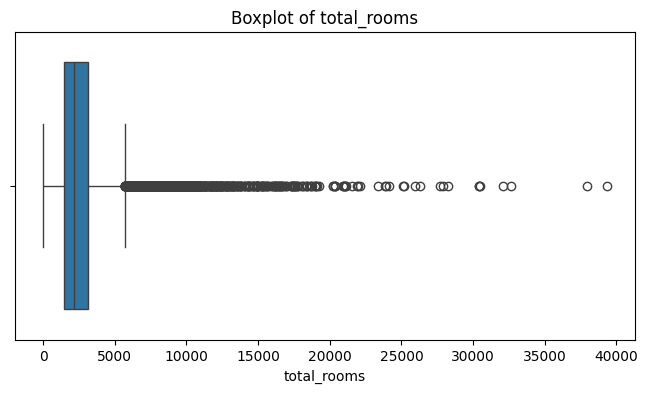

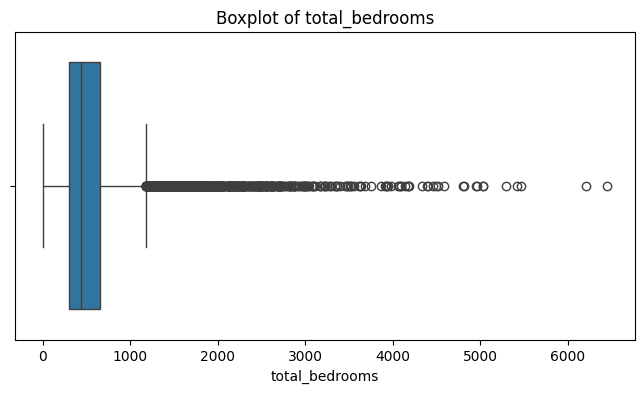

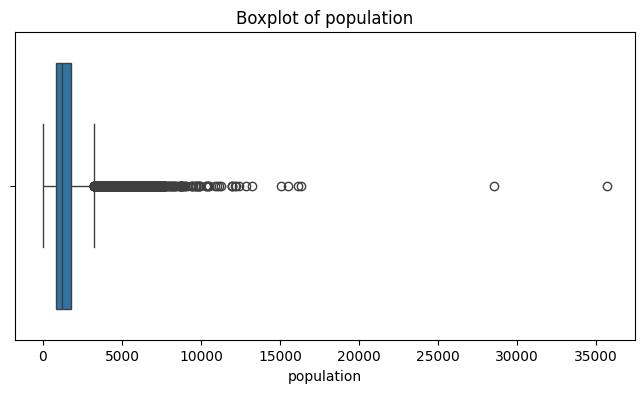

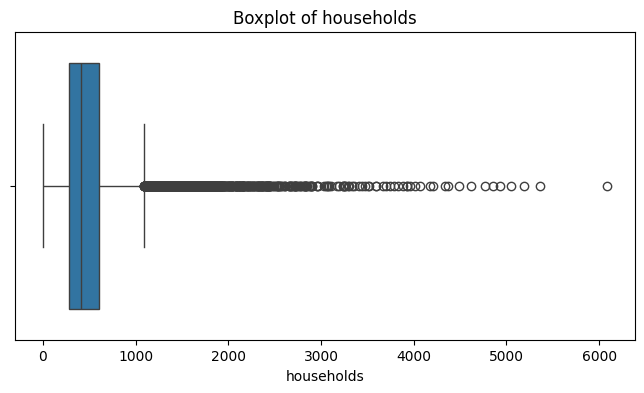

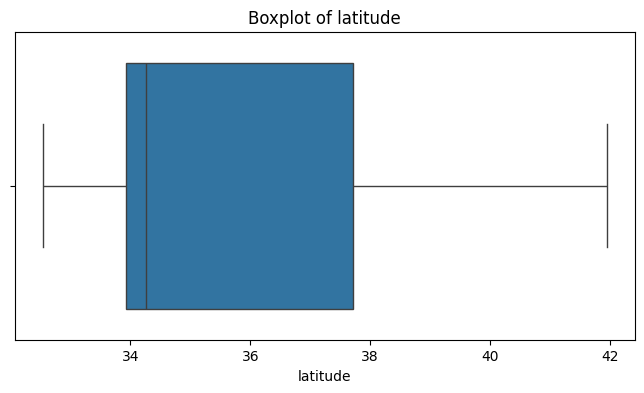

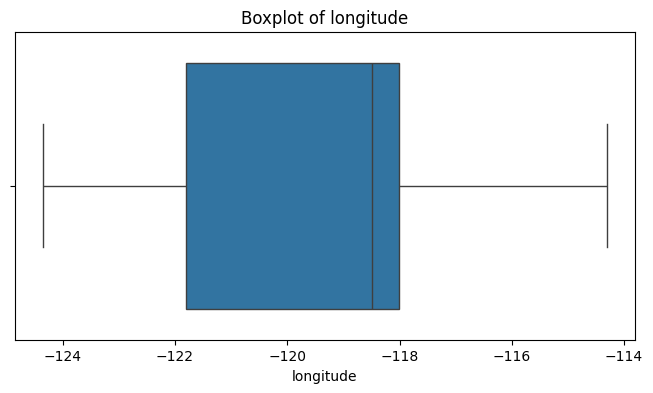

In [8]:
print("\nDetecting Outliers Using Boxplots:")

numeric_columns = houses_corrupted.select_dtypes(include=['float64', 'int64']).columns
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=houses_corrupted[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

### Outliers
- Used boxplots to identify outliers for numerical features.
- Highlighted features with a large spread or extreme values.
- Boxplots representing median income, total rooms, total bedrooms, population, and households all have a large spread and several extreme outliers past the upper whisker
- However the latter four boxplots have a larger spread than median income
- Boxplot representing median house value is the only other one with outliers as well, but there are less and the spread is much smaller
- Boxplots of housing median age, latitude and longitude have no outliers at all


Feature Distributions:


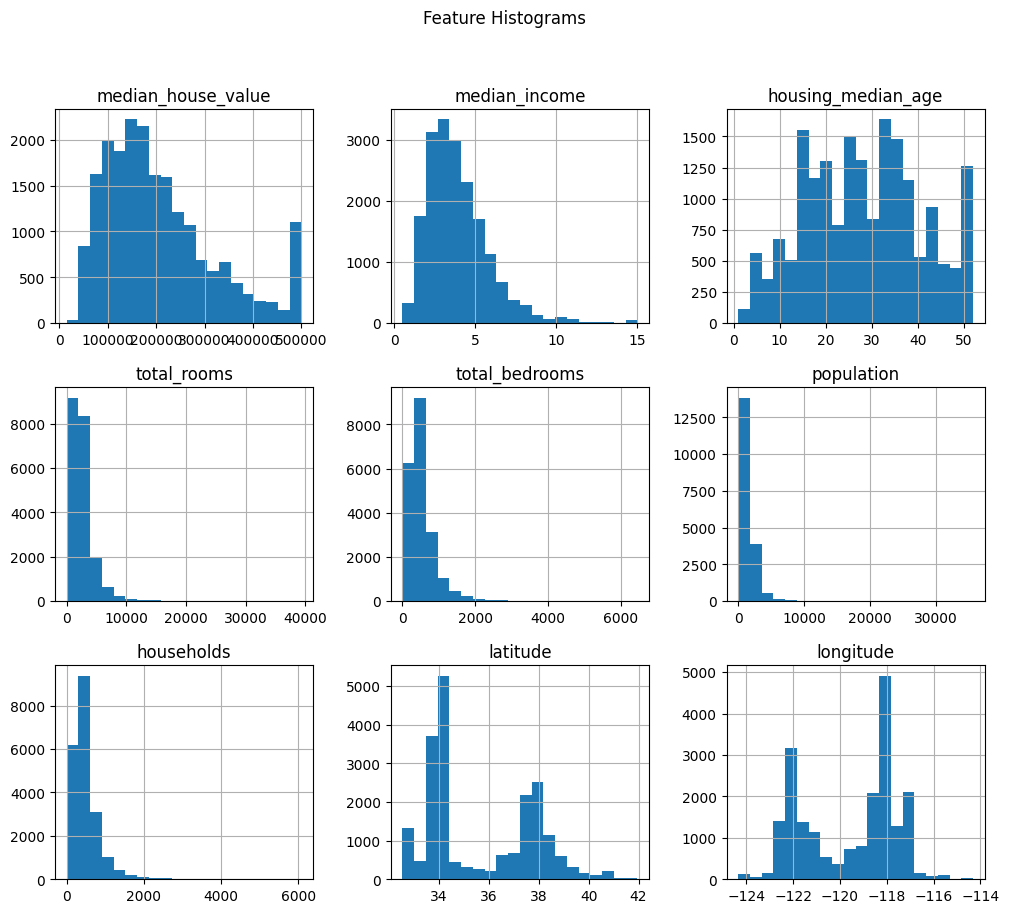

In [9]:
# Distribution of Features
print("\nFeature Distributions:")
houses_corrupted.hist(figsize=(12, 10), bins=20)
plt.suptitle("Feature Histograms")
plt.show()

### Feature Distributions
- Generated histograms for numerical columns to examine their distributions.
- Commented on skewness, normality, or multimodal patterns in features.
- Positively skewed histograms include: median income, total room, total bedrooms, population
- None seem to display any normal distribution
- Latitude and longitude show non-symmetric bimodal distribution


Correlation Matrix:


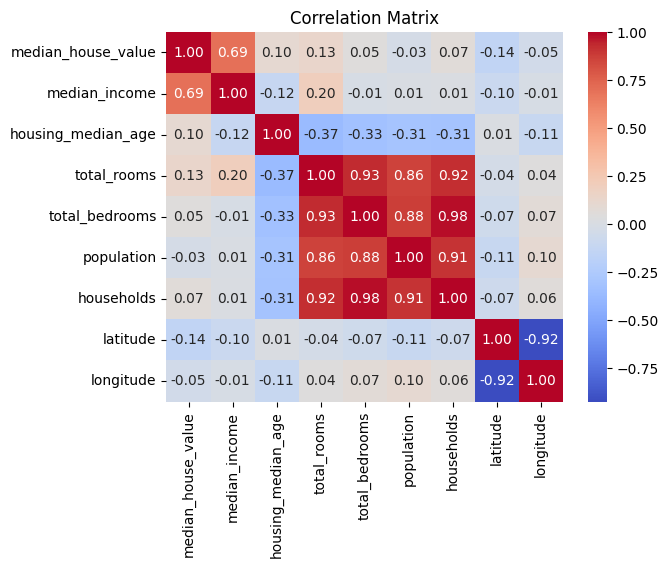

In [10]:
# Correlation Analysis
print("\nCorrelation Matrix:")
correlation_matrix = houses_corrupted.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Correlation Analysis
- Presented a correlation heatmap to identify relationships between numerical features.
- Highlighted highly correlated features that may require further investigation.
- Moderately high correlation: Median income & median house value (0.69)
- Strong positive correlation: total rooms, total bedrooms, & population all have correlation with each other (ranging from 0.88 to 0.98)
- Strong negative correlation: latitude & longitude (-0.92)

In [11]:
# Additional Exploratory Graphs (if categorical features are present)
categorical_columns = houses_corrupted.select_dtypes(include=['object']).columns
if len(categorical_columns) > 0:
    print("\nCategorical Feature Value Counts:")
    for column in categorical_columns:
        print(f"\nValue Counts for {column}:")
        display(houses_corrupted[column].value_counts())

        # Visualize Categorical Distributions
        sns.countplot(y=houses_corrupted[column])
        plt.title(f"Distribution of {column}")
        plt.show()
else:
    print("No categorical features detected.")

No categorical features detected.


### 2. Outlier Identification [10]
- Utilise a statistical outlier detection approach (i.e., **no** KNN, LOF, 1Class SVM)
- Utilise an algorithmic outlier detection method of your choice
- Compare results and decide what to do with identified outleirs
  - Include graphs, statistics, and written descriptions as appropriate
- Explain what you are doing, and why your analysis is appropriate
- Comment on benefits/detriments of statistical and algorithmic outlier detection approaches


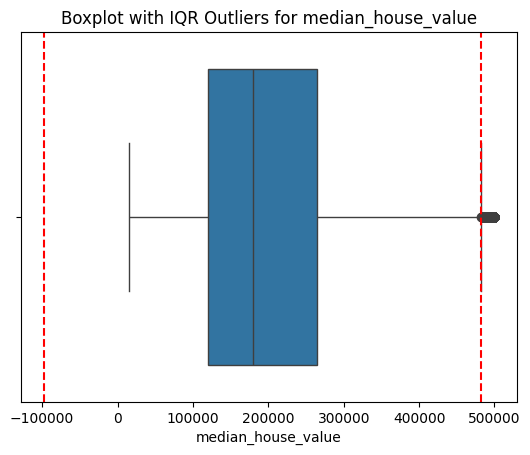

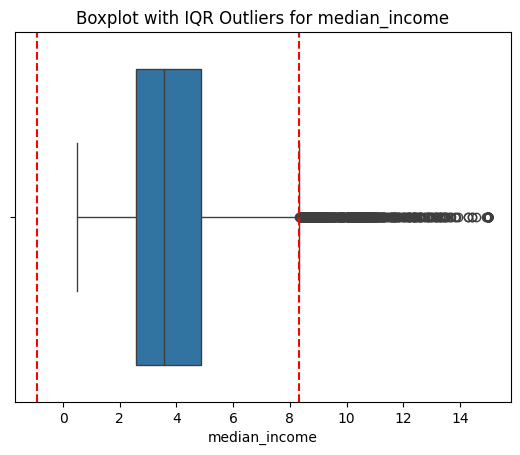

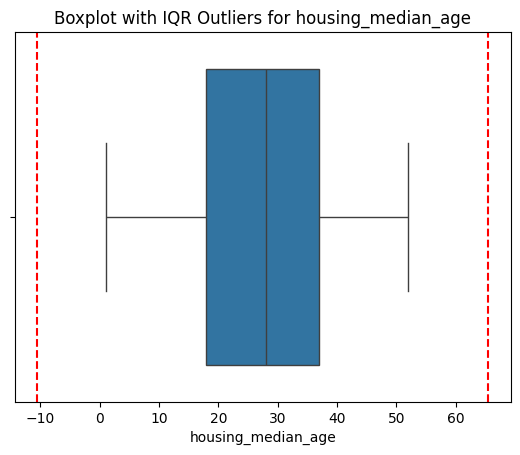

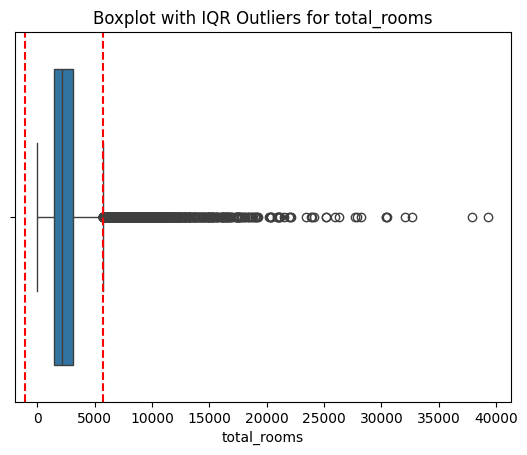

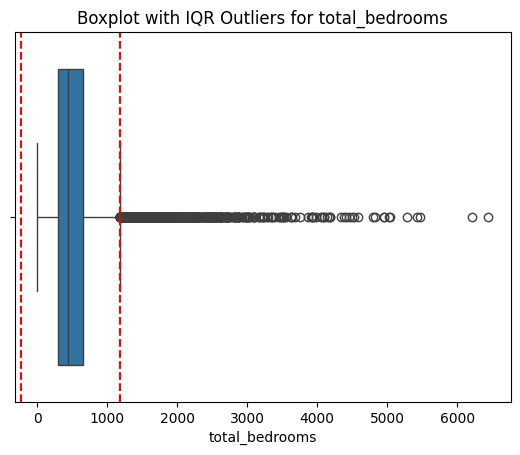

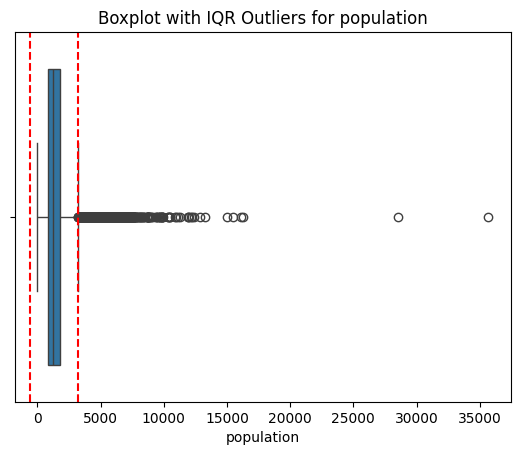

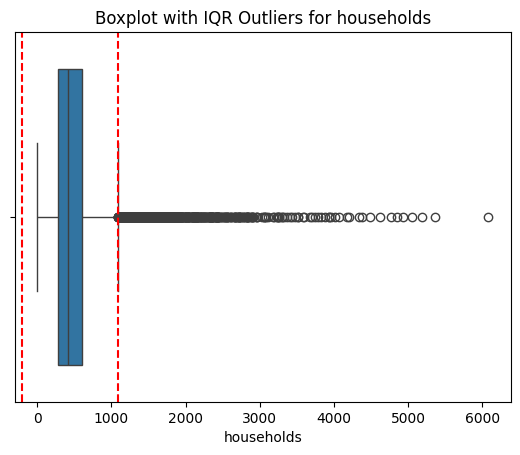

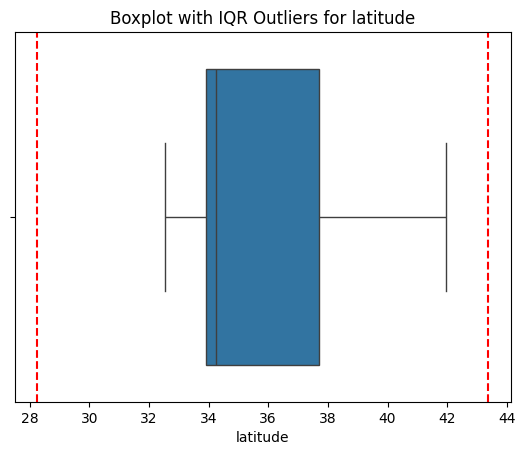

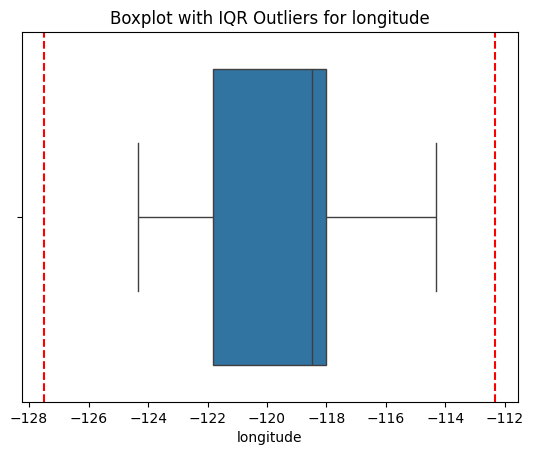

median_house_value: 1071 outliers
median_income: 562 outliers
housing_median_age: 0 outliers
total_rooms: 1287 outliers
total_bedrooms: 1282 outliers
population: 1077 outliers
households: 1220 outliers
latitude: 0 outliers
longitude: 0 outliers


In [12]:
# Statistical Outlier Detection
outliers_statistical = {}

for column in numeric_columns:
    Q1 = houses_corrupted[column].quantile(0.25)
    Q3 = houses_corrupted[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = houses_corrupted[(houses_corrupted[column] < lower_bound) | (houses_corrupted[column] > upper_bound)]
    outliers_statistical[column] = outliers

    # Visualize Outliers
    sns.boxplot(x=houses_corrupted[column])
    plt.axvline(lower_bound, color='red', linestyle='--')
    plt.axvline(upper_bound, color='red', linestyle='--')
    plt.title(f"Boxplot with IQR Outliers for {column}")
    plt.show()

# Count of outliers per feature
for column, outliers in outliers_statistical.items():
    print(f"{column}: {len(outliers)} outliers")

### Statistical Outlier Detection
Using the IQR method, outliers were identified in several numerical features:

- Median House Value: 1071 outliers detected, indicating a significant number of extreme values for house prices.
- Median Income: 562 outliers, suggesting some households with significantly higher or lower income levels compared to others.
- Total Rooms: 1287 outliers, likely due to extreme housing units with unusually high or low room counts.
- Total Bedrooms: 1282 outliers, closely aligned with the outliers in total rooms, reflecting their strong correlation.
- Population: 1077 outliers, showing areas with extraordinarily high or low populations.
- Households: 1220 outliers, further supporting the trends observed in total rooms and total bedrooms.
- Housing Median Age, Latitude, Longitude: No outliers detected, indicating these features are relatively stable without extreme deviations.

In [4]:
from sklearn.ensemble import IsolationForest

# Ensure numeric_columns contains the list of numerical features
numeric_columns = houses_corrupted.select_dtypes(include=np.number).columns.tolist()

# Handle missing data before applying Isolation Forest
non_missing_data = houses_corrupted[numeric_columns].dropna()

# Initialize and fit Isolation Forest
isolation_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
isolation_forest.fit(non_missing_data)

# Predict anomalies for non-missing rows
outlier_predictions = isolation_forest.predict(non_missing_data)

# Create a new column in the original dataset to store outlier labels
houses_corrupted['IsolationForest_Outlier'] = np.nan  # Initialize with NaN
houses_corrupted.loc[non_missing_data.index, 'IsolationForest_Outlier'] = outlier_predictions

# Count and print the number of outliers
num_outliers = sum(houses_corrupted['IsolationForest_Outlier'] == -1)
print(f"Isolation Forest detected {num_outliers} outliers")

Isolation Forest detected 753 outliers


Using Isolation Forest with a contamination rate of 5%, the algorithm detected 753 outliers across the dataset.

Key observations:

- The algorithm identified fewer outliers compared to the IQR method, potentially focusing on anomalous patterns rather than merely statistical extremes.
- Outliers are scattered across multiple features, often aligning with those detected by the statistical method, especially in features like total rooms, total bedrooms, and population.

In [8]:
# Initialize a dictionary to store statistical outliers
outliers_statistical = {}

# Iterate over numerical columns and detect outliers using IQR
for column in numeric_columns:
    Q1 = houses_corrupted[column].quantile(0.25)
    Q3 = houses_corrupted[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Collect outliers
    outliers = houses_corrupted[(houses_corrupted[column] < lower_bound) | (houses_corrupted[column] > upper_bound)]
    outliers_statistical[column] = outliers.index  # Store the indices of outliers

for column, outliers in outliers_statistical.items():
    print(f"Outliers in {column}:")
    print(outliers)  # Directly print the Index object

Outliers in median_house_value:
Index([   89,   140,   459,   489,   493,   494,   509,   510,   511,   512,
       ...
       20326, 20335, 20367, 20380, 20389, 20422, 20426, 20427, 20436, 20443],
      dtype='int64', length=1071)
Outliers in median_income:
Index([  131,   135,   155,   407,   409,   494,   510,   511,   512,   514,
       ...
       20335, 20375, 20376, 20377, 20380, 20389, 20426, 20427, 20428, 20436],
      dtype='int64', length=562)
Outliers in housing_median_age:
Index([], dtype='int64')
Outliers in total_rooms:
Index([    1,   101,   104,   185,   283,   508,   568,   570,   571,   573,
       ...
       20529, 20530, 20533, 20539, 20541, 20543, 20544, 20563, 20567, 20629],
      dtype='int64', length=1287)
Outliers in total_bedrooms:
Index([   95,    96,    98,   100,   101,   104,   112,   116,   185,   283,
       ...
       20488, 20507, 20517, 20529, 20530, 20539, 20543, 20544, 20563, 20629],
      dtype='int64', length=1282)
Outliers in population:
Index([ 

In [9]:
for column, outliers in outliers_statistical.items():
    print(f"Column: {column}, Number of Outliers: {len(outliers)}")

Column: median_house_value, Number of Outliers: 1071
Column: median_income, Number of Outliers: 562
Column: housing_median_age, Number of Outliers: 0
Column: total_rooms, Number of Outliers: 1287
Column: total_bedrooms, Number of Outliers: 1282
Column: population, Number of Outliers: 1077
Column: households, Number of Outliers: 1220
Column: latitude, Number of Outliers: 0
Column: longitude, Number of Outliers: 0


In [10]:
# Flatten all indices of statistical outliers
statistical_outliers = pd.Index([idx for indices in outliers_statistical.values() for idx in indices])

# Extract indices of algorithmic outliers
algorithmic_outliers = houses_corrupted[houses_corrupted['IsolationForest_Outlier'] == -1].index

# Compare the two sets of outliers
common_outliers = set(statistical_outliers).intersection(set(algorithmic_outliers))
print(f"Common outliers: {len(common_outliers)}")

Common outliers: 701


### Comparison of Methods
- Overlap:
  - Common outliers between the two methods: 701.
  - Indicates significant agreement between the statistical and algorithmic approaches, particularly in extreme cases.
- Differences:

  - Statistical detection flagged more outliers in features like total rooms and total bedrooms due to its rigid IQR-based threshold.
  - Algorithmic detection likely focused on multivariate anomalies and flagged fewer outliers in features like population and households.

### Actions on Outliers
- Remove or Impute:
  - Outliers in highly correlated features (e.g., total rooms, total bedrooms) might be imputed or removed to avoid skewing analyses.
  - Outliers in critical predictive features like median income and house value should be reviewed in detail to determine their relevance.
- Benefits and Drawbacks:
  - Statistical Approach:
    - Pros: Simple, interpretable, and effective for univariate outliers.
    - Cons: May flag non-anomalous extreme values as outliers; ignores multivariate relationships.
  - Algorithmic Approach:
    - Pros: Identifies complex, multivariate patterns and more relevant anomalies.
    - Cons: Computationally intensive; requires tuning (e.g., contamination rate) to balance sensitivity and specificity.

### 3. Imputation [10]
- Identify which features should be imputed and which should be removed
  - Provide a written rationale for this decision
- Impute the missing records using KNN imputation
- Impute the missing records using MICE imputation
- Compare both imputed datasets feature distributions against each other and the non-imputed data
- Build a regressor on all thre datasets
  - Use regression models to predict house median price
  - Compare regressors of non-imputed data against imputed datas
  - **Note**: If you're struggling to compare against the original dataset focus on comparing the two imputed datasets against each other


In [3]:
# Use this dataset for comparison against the imputed datasets
houses = pd.read_csv('https://raw.githubusercontent.com/PaoloMissier/CSC3831-2021-22/main/IMPUTATION/TARGET-DATASETS/ORIGINAL/houses.csv', header=0)

In [12]:
from sklearn.impute import KNNImputer

# Select numerical columns with missing values
numeric_columns_with_missing = ['median_income', 'housing_median_age', 'population']

# Create KNN imputer model
knn_imputer = KNNImputer(n_neighbors=5)

# Apply KNN imputation on the selected columns
houses_corrupted_knn_imputed = houses_corrupted.copy()
houses_corrupted_knn_imputed[numeric_columns_with_missing] = knn_imputer.fit_transform(houses_corrupted[numeric_columns_with_missing])

# Verify if imputation worked
houses_corrupted_knn_imputed.isnull().sum()


,0
median_house_value,0
median_income,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
latitude,0
longitude,0


In [5]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Create MICE imputer model
mice_imputer = IterativeImputer(max_iter=10, random_state=42)

# Apply MICE imputation on the selected columns
houses_corrupted_mice_imputed = houses_corrupted.copy()
houses_corrupted_mice_imputed[numeric_columns_with_missing] = mice_imputer.fit_transform(houses_corrupted[numeric_columns_with_missing])

# Verify if imputation worked
houses_corrupted_mice_imputed.isnull().sum()

,0
median_house_value,0
median_income,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
latitude,0
longitude,0


### Rationale for Imputation Decision

- **Features with Significant Missing Values**:
  - For **numerical features** like `median_income`, `housing_median_age`, and `population`, we have identified that they have missing values. These features contain important information about the dataset, and removing them would result in the loss of valuable insights.
  - Imputation techniques, such as **KNN Imputation**, can effectively fill in missing values by considering the similarity between data points. Since these features are numerical and may have meaningful relationships with other variables, imputing them with KNN (based on neighbors) ensures that the imputed values are consistent with other available data points.

- **Features with No or Few Missing Values**:
  - Features with **no missing values** (such as `latitude` and `longitude` in the dataset) do not require any imputation. If a feature doesn't contain missing values, there is no need to impute anything. Removing such features wouldn't make sense unless they are deemed irrelevant for prediction.
  - For **categorical variables** with minimal missing data, imputation could also be considered (e.g., using the most frequent category), but this decision would depend on how the categorical feature is related to the outcome variable and its distribution.

- **Features to Remove**:
  - If a feature contains a **large percentage of missing values** (say, above 50% or 60%) or if it doesn't add predictive power to the target variable (such as features with high cardinality, minimal variance, or poor correlation with the target), removing it may be a better option. However, in this case, no features were identified for removal based on these criteria, since `median_income`, `housing_median_age`, and `population` are significant and informative features.

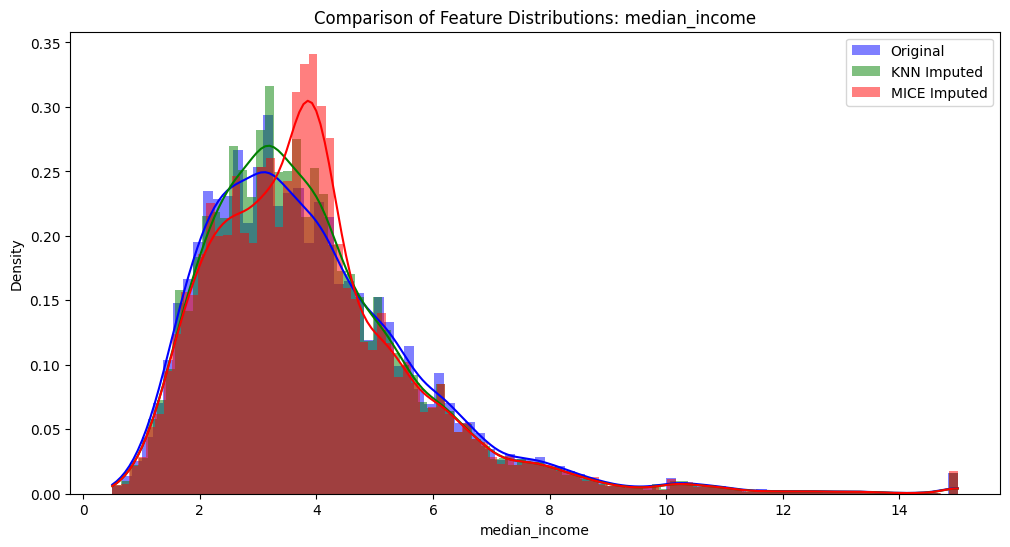

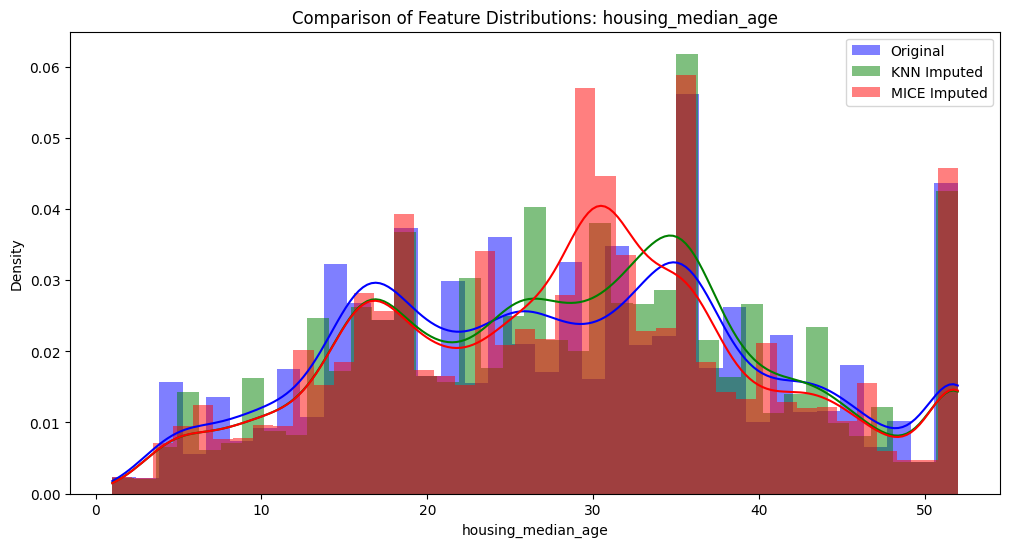

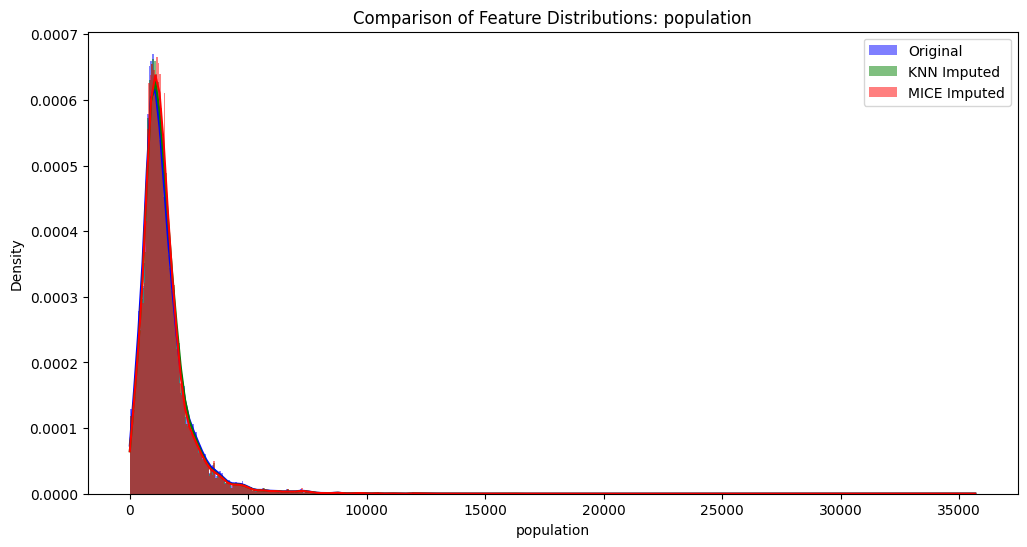

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distributions for the features with missing values
features_to_compare = ['median_income', 'housing_median_age', 'population']

# Create comparison plots
for feature in features_to_compare:
    plt.figure(figsize=(12, 6))

    # Plot original data
    sns.histplot(houses_corrupted[feature], kde=True, label='Original', color='blue', stat='density', linewidth=0)

    # Plot KNN imputed data
    sns.histplot(houses_corrupted_knn_imputed[feature], kde=True, label='KNN Imputed', color='green', stat='density', linewidth=0)

    # Plot MICE imputed data
    sns.histplot(houses_corrupted_mice_imputed[feature], kde=True, label='MICE Imputed', color='red', stat='density', linewidth=0)

    plt.legend()
    plt.title(f"Comparison of Feature Distributions: {feature}")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.show()

In [17]:
# Required Libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd
import numpy as np

# Load Data
houses_corrupted = pd.read_csv('https://raw.githubusercontent.com/PaoloMissier/CSC3831-2021-22/main/IMPUTATION/TARGET-DATASETS/CORRUPTED/HOUSES/houses_0.1_MAR.csv', header=0)
houses_corrupted.drop(["Unnamed: 0"], axis=1, inplace=True)  # Clean artifact column

# Separate features and target variable
X = houses_corrupted.drop(columns=['median_house_value'])
y = houses_corrupted['median_house_value']

# Handle missing values in the original data using SimpleImputer
simple_imputer = SimpleImputer(strategy='mean')  # We use mean imputation for simplicity
X_imputed = simple_imputer.fit_transform(X)

# Split the imputed data into training and testing sets (for model comparison)
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

# Initialize Linear Regression Model
model = LinearRegression()

# 1. Train and Evaluate on Original (Non-Imputed) Data (with imputation)
model.fit(X_train, y_train)
y_pred_original = model.predict(X_test)
mse_original = mean_squared_error(y_test, y_pred_original)

# Print MSE for original data
print(f"Mean Squared Error (Original Data - Imputed): {mse_original}")

# 2. KNN Imputation (Impute Missing Data using KNN)
knn_imputer = KNNImputer(n_neighbors=5)
X_knn_imputed = knn_imputer.fit_transform(X)  # Impute the missing values

# Split the imputed data into training and testing sets
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_knn_imputed, y, test_size=0.2, random_state=42)

# Train and Evaluate on KNN Imputed Data
model.fit(X_train_knn, y_train_knn)
y_pred_knn = model.predict(X_test_knn)
mse_knn = mean_squared_error(y_test_knn, y_pred_knn)

# Print MSE for KNN imputed data
print(f"Mean Squared Error (KNN Imputed Data): {mse_knn}")

# 3. MICE Imputation (Impute Missing Data using MICE)
mice_imputer = IterativeImputer(max_iter=10, random_state=42)
X_mice_imputed = mice_imputer.fit_transform(X)  # Impute the missing values

# Split the imputed data into training and testing sets
X_train_mice, X_test_mice, y_train_mice, y_test_mice = train_test_split(X_mice_imputed, y, test_size=0.2, random_state=42)

# Train and Evaluate on MICE Imputed Data
model.fit(X_train_mice, y_train_mice)
y_pred_mice = model.predict(X_test_mice)
mse_mice = mean_squared_error(y_test_mice, y_pred_mice)

# Print MSE for MICE imputed data
print(f"Mean Squared Error (MICE Imputed Data): {mse_mice}")

# Final Comparison: Comparing MSE for Original, KNN Imputed, and MICE Imputed Datasets
print("\nComparison of Models:")
print(f"Original Data - MSE (Imputed): {mse_original}")
print(f"KNN Imputed Data - MSE: {mse_knn}")
print(f"MICE Imputed Data - MSE: {mse_mice}")

Mean Squared Error (Original Data - Imputed): 5145564670.174777
Mean Squared Error (KNN Imputed Data): 4998217426.820118
Mean Squared Error (MICE Imputed Data): 5226944856.112461

Comparison of Models:
Original Data - MSE (Imputed): 5145564670.174777
KNN Imputed Data - MSE: 4998217426.820118
MICE Imputed Data - MSE: 5226944856.112461


In [18]:
# Required Libraries
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd
import numpy as np

# Load Corrupted Data (With Missing Values)
houses_corrupted = pd.read_csv('https://raw.githubusercontent.com/PaoloMissier/CSC3831-2021-22/main/IMPUTATION/TARGET-DATASETS/CORRUPTED/HOUSES/houses_0.1_MAR.csv', header=0)
houses_corrupted.drop(["Unnamed: 0"], axis=1, inplace=True)  # Clean artifact column

# Load Original Data (For Comparison)
houses = pd.read_csv('https://raw.githubusercontent.com/PaoloMissier/CSC3831-2021-22/main/IMPUTATION/TARGET-DATASETS/ORIGINAL/houses.csv', header=0)

# Separate features and target variable for both datasets
X_corrupted = houses_corrupted.drop(columns=['median_house_value'])
y_corrupted = houses_corrupted['median_house_value']
X_original = houses.drop(columns=['median_house_value'])
y_original = houses['median_house_value']

# 1. Impute Original Corrupted Data using SimpleImputer (mean imputation)
from sklearn.impute import SimpleImputer
simple_imputer = SimpleImputer(strategy='mean')
X_corrupted_imputed = simple_imputer.fit_transform(X_corrupted)

# 2. KNN Imputation
knn_imputer = KNNImputer(n_neighbors=5)
X_knn_imputed = knn_imputer.fit_transform(X_corrupted)

# 3. MICE Imputation (Iterative Imputation)
mice_imputer = IterativeImputer(max_iter=10, random_state=42)
X_mice_imputed = mice_imputer.fit_transform(X_corrupted)

# Split the imputed data into training and testing sets (for model comparison)
X_train_corrupted, X_test_corrupted, y_train_corrupted, y_test_corrupted = train_test_split(X_corrupted_imputed, y_corrupted, test_size=0.2, random_state=42)
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_knn_imputed, y_corrupted, test_size=0.2, random_state=42)
X_train_mice, X_test_mice, y_train_mice, y_test_mice = train_test_split(X_mice_imputed, y_corrupted, test_size=0.2, random_state=42)

# Initialize Linear Regression Model
model = LinearRegression()

# 1. Train and Evaluate on Original (Non-Imputed) Data
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(X_original, y_original, test_size=0.2, random_state=42)

model.fit(X_train_original, y_train_original)
y_pred_original = model.predict(X_test_original)
mse_original = mean_squared_error(y_test_original, y_pred_original)

# 2. Train and Evaluate on Corrupted (Imputed) Data - SimpleImputer
model.fit(X_train_corrupted, y_train_corrupted)
y_pred_corrupted = model.predict(X_test_corrupted)
mse_corrupted = mean_squared_error(y_test_corrupted, y_pred_corrupted)

# 3. Train and Evaluate on KNN Imputed Data
model.fit(X_train_knn, y_train_knn)
y_pred_knn = model.predict(X_test_knn)
mse_knn = mean_squared_error(y_test_knn, y_pred_knn)

# 4. Train and Evaluate on MICE Imputed Data
model.fit(X_train_mice, y_train_mice)
y_pred_mice = model.predict(X_test_mice)
mse_mice = mean_squared_error(y_test_mice, y_pred_mice)

# Print the results (Mean Squared Errors)
print("\nComparison of Models (MSE):")
print(f"Original Data (Non-Imputed) - MSE: {mse_original}")
print(f"Corrupted Data (SimpleImputer Imputation) - MSE: {mse_corrupted}")
print(f"KNN Imputed Data - MSE: {mse_knn}")
print(f"MICE Imputed Data - MSE: {mse_mice}")


Comparison of Models (MSE):
Original Data (Non-Imputed) - MSE: 4918556441.477823
Corrupted Data (SimpleImputer Imputation) - MSE: 5145564670.174777
KNN Imputed Data - MSE: 4998217426.820118
MICE Imputed Data - MSE: 5226944856.112461


### 4. Conclusions & Throughts [3]
- Disucss methods used for anomaly detection, pros/cons of each method
- Disucss challenges/difficulties in anomaly detection implementation
- Discuss methods used for imputation, pros/cons of each method
- Discuss challenges/difficulties in imputation implementation

## TASK 4: Conclusions & Thoughts

### Anomaly Detection Methods:

#### 1. **Statistical Outlier Detection**
   - **Method Used**: Boxplots were used to visually identify features with extreme values or large spreads. Statistical methods identified outliers in numerical features such as `median_house_value`, `median_income`, `total_rooms`, etc.
   - **Pros**:
     - Simple to implement and understand.
     - Provides a clear visual representation of outliers, making it easy to identify and analyze extreme values.
   - **Cons**:
     - Limited by the assumption of normality (i.e., boxplots work best when data follows a roughly normal distribution).
     - May not detect outliers in high-dimensional data as effectively as algorithmic methods.
   
#### 2. **Algorithmic Outlier Detection (Isolation Forest)**
   - **Method Used**: Isolation Forest, a machine learning algorithm, was used to detect outliers in a high-dimensional dataset. It identifies anomalies by isolating points that are different from the majority of the data.
   - **Pros**:
     - Effective in high-dimensional data and for identifying outliers in large datasets.
     - It works well even when the distribution of data is unknown or complex.
   - **Cons**:
     - Computationally more expensive, especially for large datasets with many features.
     - Sensitive to the choice of hyperparameters like `n_estimators` and `contamination`, which may require tuning for optimal results.
   
#### Challenges in Anomaly Detection:
   - **Data Complexity**: Detecting outliers in datasets with high dimensions and complex distributions can be difficult. Methods like Isolation Forest are sensitive to the data’s nature and might require parameter tuning.
   - **Misidentification of Outliers**: Sometimes, values that are not outliers in a practical sense are flagged as anomalies, especially in skewed or multimodal data.

---

### Imputation Methods:

#### 1. **KNN Imputation**
   - **Method Used**: KNN Imputation was applied to impute missing values in features such as `median_income`, `housing_median_age`, and `population`.
   - **Pros**:
     - Works well when the data is structured and has meaningful relationships between features.
     - Simple to implement with good performance for many types of data.
   - **Cons**:
     - Computationally intensive for large datasets, as it requires finding the k nearest neighbors for each data point.
     - Sensitive to the choice of `k` (the number of neighbors), which might affect the imputation results.
   
#### 2. **MICE (Multiple Imputation by Chained Equations)**
   - **Method Used**: MICE Imputation was used as another approach to impute missing data, based on the relationships between variables, and performing multiple imputations for more robust predictions.
   - **Pros**:
     - Provides more robust estimates by generating multiple imputations and capturing uncertainty in the missing values.
     - Useful when the data is missing at random and multiple features are correlated.
   - **Cons**:
     - Computationally expensive, especially with large datasets or many variables.
     - Requires more advanced knowledge and fine-tuning to get the best results.

#### Challenges in Imputation:
   - **Missing Data Patterns**: Imputation works well when missing values are missing at random, but it becomes less reliable when data is missing systematically (e.g., due to an underlying pattern or bias).
   - **Choice of Imputation Method**: Selecting the right imputation method (KNN vs MICE) can be difficult, especially when working with complex datasets. It's important to balance computational cost and imputation accuracy.
   - **Impact on Model Performance**: Imputation introduces approximations into the data, which can impact model performance. The results from imputed datasets can vary depending on how missing values were handled, and this needs to be carefully evaluated using performance metrics such as Mean Squared Error (MSE).

---

### Summary:
In this analysis, we used statistical and algorithmic methods for anomaly detection and different imputation techniques to handle missing values in the dataset. Both **Isolation Forest** and **boxplot-based detection** provided useful insights into outlier detection, with algorithmic methods proving effective for complex datasets. Similarly, **KNN** and **MICE imputation** showed their strengths and weaknesses, with KNN being efficient and easy to apply, while MICE offered more robust results but required more computational resources.

The challenges in anomaly detection and imputation are primarily centered around the complexity of the dataset, computational costs, and ensuring that imputed values maintain the integrity of the data. By understanding these challenges and methods, we can make more informed decisions when handling missing data and outliers in machine learning tasks.